# Comparação Baseline × Configuração Final

Confronta o desempenho das versões baseline de cada arquitetura com a configuração final após todas as fases de otimização, evidenciando o ganho acumulado ao longo do processo experimental.

**Configurações comparadas por arquitetura:**

| Identificador | Descrição                                                                                                   |
| ------------- | ----------------------------------------------------------------------------------------------------------- |
| `*-baseline`  | normalização `preprocess_input`, data aug ativado, sem class weight, learning rate `0.001`, threshold `0.5` |
| `*-final-1`   | melhor AUC-ROC, threshold otimizado pelo índice de Youden                                                   |
| `*-final-2`   | melhor equilíbrio recall/especificidade (data aug + class weight), threshold otimizado                      |

A escolha do representante de cada arquitetura foi baseada nos resultados do notebook anterior (`06_optimal_threshold`), priorizando a configuração com maior estabilidade entre runs (menor desvio padrão) e melhor equilíbrio entre as métricas clínicas relevantes. O objetivo é avaliar se a sequência de otimizações produziu ganho real e consistente em relação ao ponto de partida.

## Preparação do ambiente e carregamento dos experimentos

Clonagem do repositório do GitHub

In [1]:
%cd /content
!git clone https://github.com/amartinsmg/classification-of-medical-images-using-cnn.git
%cd /content/classification-of-medical-images-using-cnn

/content
Cloning into 'classification-of-medical-images-using-cnn'...
remote: Enumerating objects: 2185, done.
remote: Counting objects: 100% (261/261), done.
remote: Compressing objects: 100% (150/150), done.
remote: Total 2185 (delta 161), reused 190 (delta 110), pack-reused 1924 (from 1)
Receiving objects: 100% (2185/2185), 18.34 MiB | 23.33 MiB/s, done.
Resolving deltas: 100% (1053/1053), done.
/content/classification-of-medical-images-using-cnn


Montagem do Google Drive

In [2]:
from google.colab import drive

drive.mount("/content/drive")

BASE_PATH = "/content/drive/MyDrive/classification-of-medical-images-using-cnn/"

Mounted at /content/drive


Definição dos:
- Nomes dos experimentos analisados
- Caminho relativo do diretório onde as comparações serão salvas
- Caminho da pasta onde os resultados dos modelos estão salvos no Google Drive
- Caminho da pasta onde as comparações serão salvas no Google Drive

In [3]:
experiment_names = ["resnet-baseline", "resnet-final-1",
                  "densenet-baseline", "densenet-final-2",
                  "efficientnet-baseline", "efficientnet-final-1"]

COMPARISON_PATH = "comparisons/07-baseline-vs-final"
RESULT_PATH = BASE_PATH + "results"
SAVE_DIR = BASE_PATH + COMPARISON_PATH

Carregamento dos experimentos

In [4]:
from src.analyses import load_experiments

experiments = load_experiments(RESULT_PATH, experiment_names)


## Visualização das métricas finais com média e desvio padrão

In [16]:
from src.analyses import metrics_table
from IPython.display import display

metrics = metrics_table(experiments)
display(metrics)

,accuracy-mean,accuracy-std,precision-mean,precision-std,recall-mean,recall-std,f1-score-mean,f1-score-std,specificity-mean,specificity-std,auc-roc-mean,auc-roc-std
experiment,,,,,,,,,,,,
resnet-baseline,0.879808,0.024234,0.885167,0.056200,0.936752,0.042306,0.907570,0.013514,0.784900,0.129684,0.954208,0.005962
resnet-final-1,0.905449,0.002266,0.945295,0.002470,0.900855,0.001209,0.922539,0.001810,0.913105,0.004029,0.963566,0.003803
densenet-baseline,0.855769,0.019275,0.831175,0.031108,0.968376,0.017433,0.893862,0.010904,0.668091,0.080355,0.956991,0.001435
densenet-final-2,0.897436,0.002617,0.930336,0.017147,0.904274,0.016792,0.916808,0.001657,0.886040,0.032421,0.956323,0.000575
efficientnet-baseline,0.866987,0.022664,0.848382,0.044925,0.964103,0.025726,0.901138,0.013308,0.705128,0.102979,0.961047,0.002615
efficientnet-final-1,0.911325,0.006044,0.947609,0.007872,0.908547,0.016922,0.927508,0.005720,0.915954,0.014527,0.969923,0.001793


- Os modelos resnet-final-1 e efficientnet-final-1 obtiveram melhores resultados médios em todas as métricas, exceto no recall, e mais estabilidade nos resultados quando comparados aos respectivos modelos baseline.
- O modelo densenet-final-2 apresentou piores recall e AUC-ROC que o modelo densenet-baseline, apesar disso, se mostrou mais estável em todos os resultados.

## Visualização dos gráficos dos experimentos com ResNet

- Visualização das curvas ROC dos experimentos
- Visualização da matriz de confusão de cada experimento

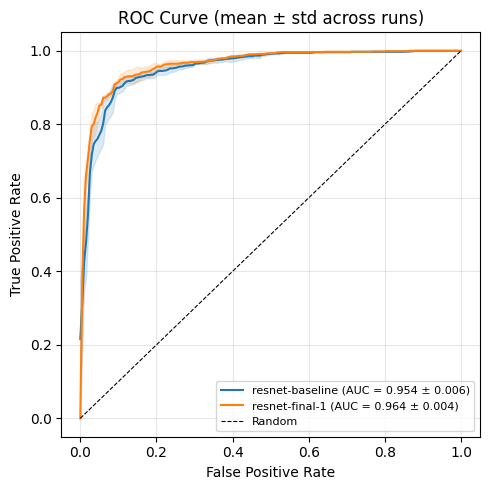

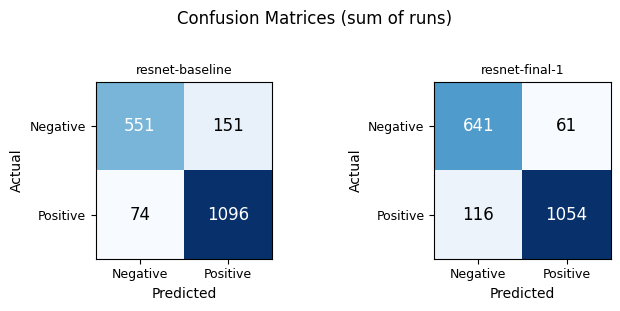

In [6]:
from src.analyses import plot_roc_curves, plot_confusion_matrices
import matplotlib.pyplot as plt

resnet_exps = [exp for exp in experiments if exp.get("name").startswith("resnet")]

fig_roc = plot_roc_curves(resnet_exps)
fig_cm = plot_confusion_matrices(resnet_exps)

plt.show()

## Visualização dos gráficos dos experimentos com DenseNet

- Visualização das curvas ROC dos experimentos
- Visualização da matriz de confusão de cada experimento

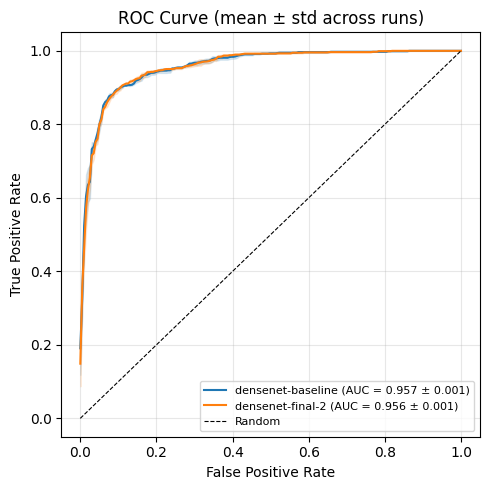

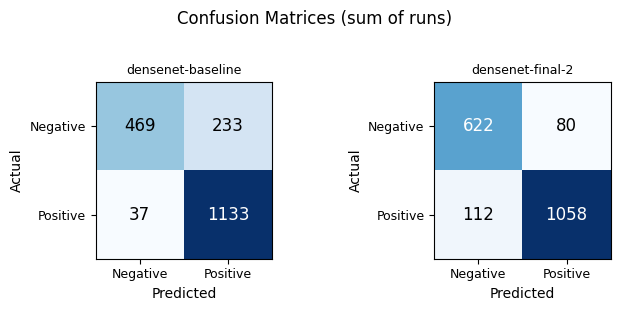

In [7]:
densenet_exps = [exp for exp in experiments if exp.get("name").startswith("densenet")]

fig_roc = plot_roc_curves(densenet_exps)
fig = plot_confusion_matrices(densenet_exps)

plt.show()

## Visualização dos gráficos dos experimentos com EfficientNet

- Visualização das curvas ROC dos experimentos
- Visualização da matriz de confusão de cada experimento

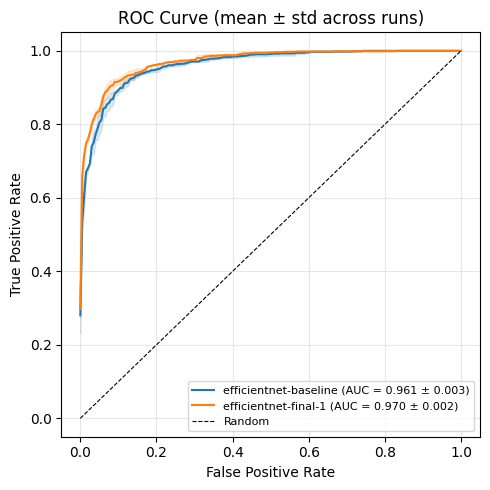

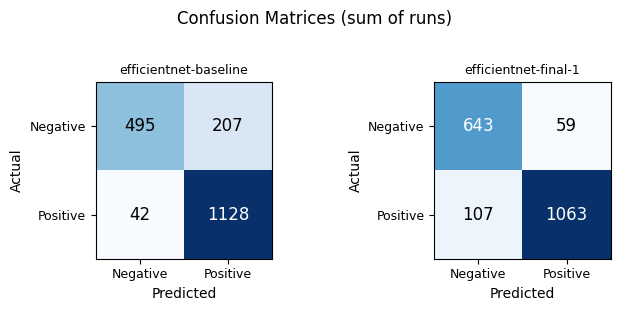

In [8]:
efficientnet_exps = [exp for exp in experiments if exp.get("name").startswith("efficientnet")]

fig_roc = plot_roc_curves(efficientnet_exps)
fig = plot_confusion_matrices(efficientnet_exps)

plt.show()

## Conclusão

Os modelos finais apresentaram, no geral, resultados mais sólidos e maior capacidade discriminativa, com equilíbrio muito maior entre falsos positivos e falsos negativos, o que acaba se traduzindo numa maior confiabilidade clínica. Contudo, houve um aumento na taxa de falsos negativos o que, num cenário de uso real, acarretaria um maior número de pacientes doentes não diagnosticados, correndo o risco de não receberem o tratamento adequado em tempo hábil. Estes resultados mostram que, para estes modelos, o ideal seria a geração de um ranking de risco e não a decisão binária entre doente e normal, deixando a cargo de um especialista humano a decisão final. Esta abordagem ajudaria numa triagem inicial, o que poderia agilizar o atendimento, sobretudo em casos de sobrecarga do sistema de saúde.

## Salvamento da comparação completa

A comparação completa é salva no Google Drive

In [20]:
from src.analyses import full_comparison

_ = full_comparison(
  base_result_dir=RESULT_PATH,
  experiment_names=experiment_names,
  history_metrics=["accuracy", "loss"],
  show_plot=False,
  save_dir=SAVE_DIR,
  separe_archs=True
)


Results saved in /content/drive/MyDrive/classification-of-medical-images-using-cnn/comparisons/07-baseline-vs-final


Upload da tabela e dos gráficos para o DagsHub

In [ ]:
%pip install -q dvc dagshub

import dagshub
from google.colab import userdata

dagshub.auth.add_app_token(token=userdata.get("DAGSHUB_TOKEN"))

DAGSHUB_REPO = "amartinsmg/classification-of-medical-images-using-cnn"

dagshub.upload_files(
    DAGSHUB_REPO,
    local_path=SAVE_DIR,
    remote_path=COMPARISON_PATH,
    force=True
)